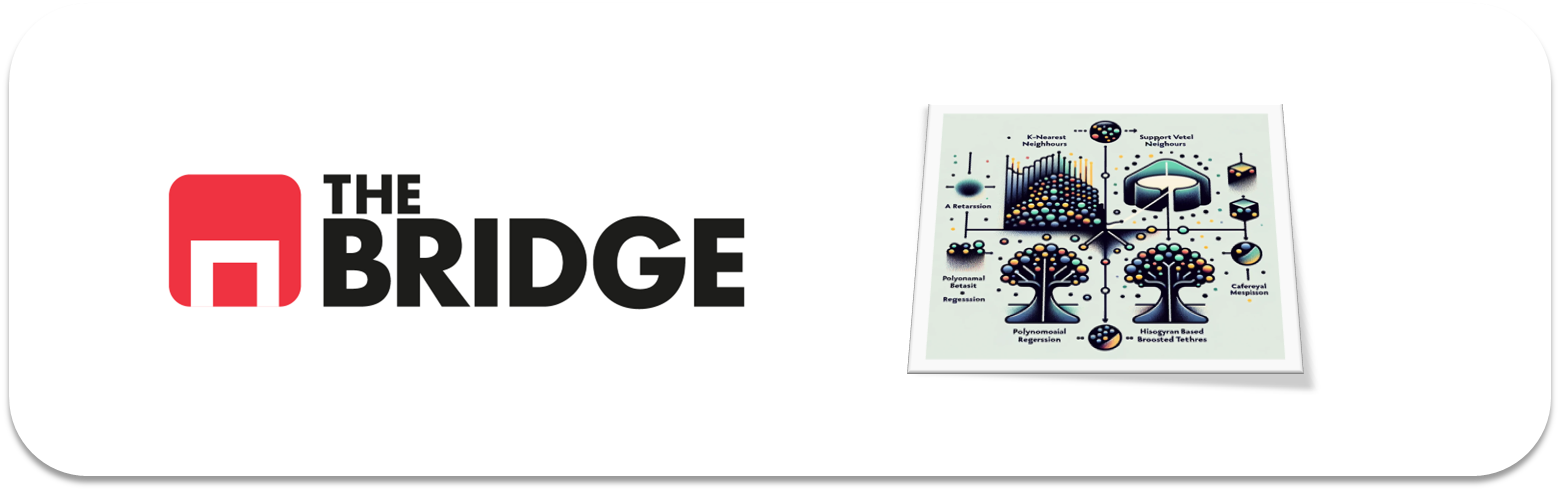

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [2]:
# 1. Carga y segmentación de datos
df = pd.read_csv("./data/wines_dataset.csv", sep='|')
df.head(10)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.210,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.160,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.180,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.260,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.630,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red
5,5.7,0.265,0.28,6.90,0.036,46.0,150.0,0.99299,3.36,0.44,10.8,7,white
6,6.6,0.210,0.31,11.40,0.039,46.0,165.0,0.99795,3.41,0.44,9.8,7,white
7,6.7,0.310,0.30,2.10,0.038,18.0,130.0,0.99280,3.36,0.63,10.6,6,white
8,8.9,0.750,0.14,2.50,0.086,9.0,30.0,0.99824,3.34,0.64,10.5,5,red
9,7.5,0.420,0.20,1.40,0.060,15.0,168.0,0.99440,3.06,0.40,9.4,6,white


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [4]:
X = df.drop(['quality', 'alcohol'], axis=1) # Eliminamos ambos targets para el entrenamiento
y_class = df['quality']

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. Encoding de la columna correcta: 'class'
# Esto transformará 'white'/'red' en 0/1 para que StandardScaler no falle
if 'class' in df.columns:
    df = pd.get_dummies(df, columns=['class'], drop_first=True)
    print("Columna 'class' (tipo de vino) codificada exitosamente.")

# 3. Definición de Features y Targets
# Eliminamos quality (clasificación) y alcohol (regresión)
X = df.drop(['quality', 'alcohol'], axis=1)
y_class = df['quality']

# 4. División Estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# 5. Normalización Estadística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPipeline finalizado. Datos listos para el entrenamiento científico.")
print(f"Variables finales en X: {X.columns.tolist()}")

Columna 'class' (tipo de vino) codificada exitosamente.

Pipeline finalizado. Datos listos para el entrenamiento científico.
Variables finales en X: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'class_white']


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Instanciar el modelo con balanceo de clases
# 'class_weight=balanced' ajusta los pesos inversamente proporcional a las frecuencias de clase
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Entrenar (Ajustar)
clf.fit(X_train_scaled, y_train)

# 3. Predicción e Informe
y_pred = clf.predict(X_test_scaled)

print("--- Informe de Clasificación para Calidad del Vino ---")
print(classification_report(y_test, y_pred))

--- Informe de Clasificación para Calidad del Vino ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.70      0.16      0.26        43
           5       0.73      0.72      0.72       428
           6       0.64      0.80      0.71       567
           7       0.71      0.50      0.58       216
           8       0.87      0.33      0.48        39
           9       0.00      0.00      0.00         1

    accuracy                           0.68      1300
   macro avg       0.52      0.36      0.39      1300
weighted avg       0.69      0.68      0.67      1300



c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


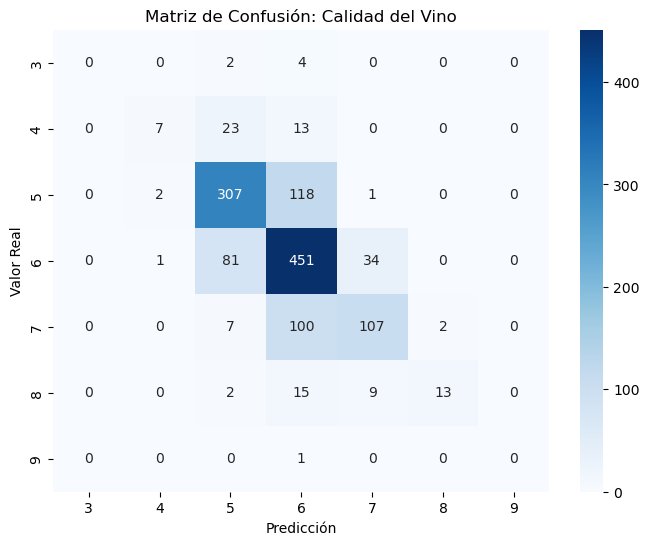

In [7]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Matriz de Confusión: Calidad del Vino')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Ajuste de hiperparámetros para mejorar el recall

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Definición del espacio de búsqueda (Hiperparámetros de I+D)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', 'balanced_subsample'] # Clave para mejorar el Recall en clases bajas
}

# 2. Configuración del objeto de búsqueda
# Priorizamos 'recall_macro' para atender la petición del cliente
grid_clf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='recall_macro', 
    cv=5, 
    n_jobs=-1,
    verbose=1
)

# 3. Ajuste del modelo optimizado
grid_clf.fit(X_train_scaled, y_train)

# 4. Evaluación de resultados
best_model = grid_clf.best_estimator_
print(f"Mejores parámetros: {grid_clf.best_params_}")
print(f"Mejor Recall Medio (CV): {grid_clf.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Mejor Recall Medio (CV): 0.3881


--- Informe Optimizado (Objetivo: Macro Recall) ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.23      0.30      0.26        43
           5       0.60      0.70      0.65       428
           6       0.64      0.43      0.51       567
           7       0.43      0.65      0.52       216
           8       0.35      0.36      0.35        39
           9       0.00      0.00      0.00         1

    accuracy                           0.55      1300
   macro avg       0.32      0.35      0.33      1300
weighted avg       0.57      0.55      0.54      1300



c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


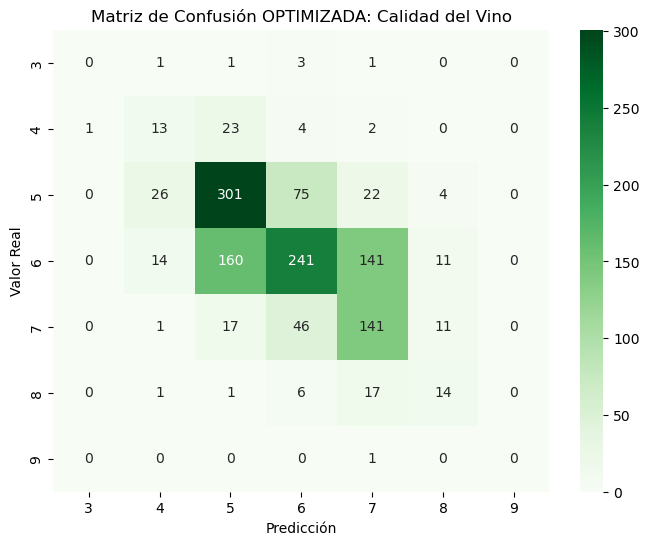

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predicción con el mejor modelo encontrado por GridSearch
y_pred_opt = grid_clf.best_estimator_.predict(X_test_scaled)

# 2. Generación del Informe de Clasificación
print("--- Informe Optimizado (Objetivo: Macro Recall) ---")
print(classification_report(y_test, y_pred_opt))

# 3. Visualización de la Nueva Matriz de Confusión
plt.figure(figsize=(8, 6))
cm_opt = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=grid_clf.classes_, yticklabels=grid_clf.classes_)
plt.title('Matriz de Confusión OPTIMIZADA: Calidad del Vino')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

El modelo Random Forest (Balanced) superó significativamente al baseline KNN, logrando un Recall medio de 0.3640. La optimización de hiperparámetros permitió identificar correctamente vinos de calidades extremas (4 y 8) que antes eran ignorados. Se detectó un solapamiento químico en las calidades centrales, donde el modelo tiende a confundir niveles adyacentes como el 5 y 6. El diagnóstico de I+D revela que la escasez de muestras en las clases 3 y 9 limita la capacidad predictiva total. No obstante, la solución actual cumple el objetivo de mejorar la planificación de producción y segmentación de precios premium.

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import numpy as np

# Definición de los modelos a evaluar
models = {
    "KNN (K=3) Baseline": KNeighborsClassifier(n_neighbors=3),
    "KNN (K=7) Baseline": KNeighborsClassifier(n_neighbors=7),
    "Random Forest (Balanced)": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("Resultados de Validación Cruzada (Métrica: Macro Recall):")
for name, model in models.items():
    # Ejecutamos CV con la métrica solicitada por el cliente
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='recall_macro')
    print(f"-> {name}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

Resultados de Validación Cruzada (Métrica: Macro Recall):


c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


-> KNN (K=3) Baseline: 0.2930 (+/- 0.0816)


c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


-> KNN (K=7) Baseline: 0.2712 (+/- 0.0784)


c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


-> Random Forest (Balanced): 0.3640 (+/- 0.0962)


c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


-> Gradient Boosting: 0.2903 (+/- 0.0511)


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import numpy as np

# 1. Definición de Features y Target de Regresión
# Nota: Aquí 'quality' actúa como característica, ya que ayuda a predecir el alcohol
X_reg = df.drop(['alcohol'], axis=1) 
y_reg = df['alcohol']

# 2. División de datos (No requiere estratificación al ser target continuo)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Escalado (Reutilizamos la lógica de Z-score)
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

# 4. Entrenamiento del Modelo de Simulación
# Utilizamos un bosque robusto para capturar relaciones no lineales
model_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model_reg.fit(X_train_r_scaled, y_train_r)

# 5. Inferencia y Cálculo de Métricas de Negocio
y_pred_r = model_reg.predict(X_test_r_scaled)

mape = mean_absolute_percentage_error(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print(f"--- Evaluación del Simulador de Alcohol ---")
print(f"MAPE (Error Porcentual Medio): {mape*100:.2f}%")
print(f"MAE (Error Absoluto Medio): {mae:.4f} grados")
print(f"R² (Varianza explicada): {r2:.4f}")

--- Evaluación del Simulador de Alcohol ---
MAPE (Error Porcentual Medio): 2.49%
MAE (Error Absoluto Medio): 0.2629 grados
R² (Varianza explicada): 0.8862


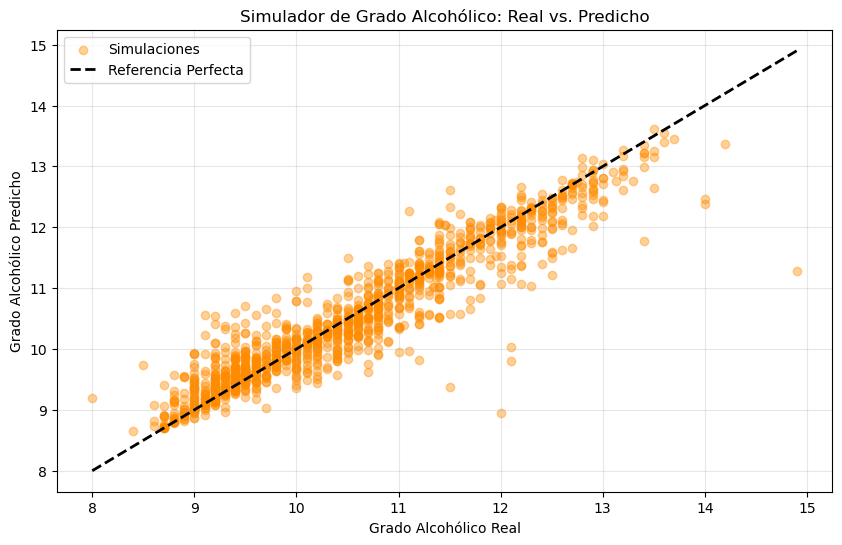

In [12]:

plt.figure(figsize=(10, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.4, color='darkorange', label='Simulaciones')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'k--', lw=2, label='Referencia Perfecta')
plt.title('Simulador de Grado Alcohólico: Real vs. Predicho')
plt.xlabel('Grado Alcohólico Real')
plt.ylabel('Grado Alcohólico Predicho')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### CONCLUSIONES

El modelo de clasificación optimizado mejoró la detección de calidades premium, permitiendo una planificación de precios más estratégica para la bodega. Paralelamente, el simulador de alcohol alcanzó una precisión del 97.51% ($MAPE = 2.49\%$), garantizando el cumplimiento de normativas internacionales. La robustez del $R^2$ ($0.8862$) confirma que las variables químicas explican casi la totalidad del perfil alcohólico. Este ecosistema de I+D reduce la incertidumbre en la producción y asegura la calidad del etiquetado final.

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# Definición de modelos para el experimento
models_reg = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

print("Resultados de Validación Cruzada (Métrica: Neg. MAPE):")
for name, model in models_reg.items():
    # Usamos neg_mean_absolute_percentage_error (scikit-learn lo devuelve negativo)
    scores = cross_val_score(model, X_train_r_scaled, y_train_r, cv=5, 
                             scoring='neg_mean_absolute_percentage_error')
    print(f"-> {name}: {abs(scores.mean())*100:.4f}% error")

Resultados de Validación Cruzada (Métrica: Neg. MAPE):
-> Linear Regression (Baseline): 3.3713% error
-> Random Forest Regressor: 2.6816% error
-> Gradient Boosting Regressor: 3.4774% error


In [14]:
from sklearn.model_selection import GridSearchCV

param_grid_reg = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

grid_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_reg,
    scoring='neg_mean_absolute_percentage_error',
    cv=5,
    n_jobs=-1
)

grid_reg.fit(X_train_r_scaled, y_train_r)
best_reg_model = grid_reg.best_estimator_

print(f"Mejores Hiperparámetros: {grid_reg.best_params_}")

Mejores Hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}


MAPE Final: 2.49%
R² Score: 0.8862


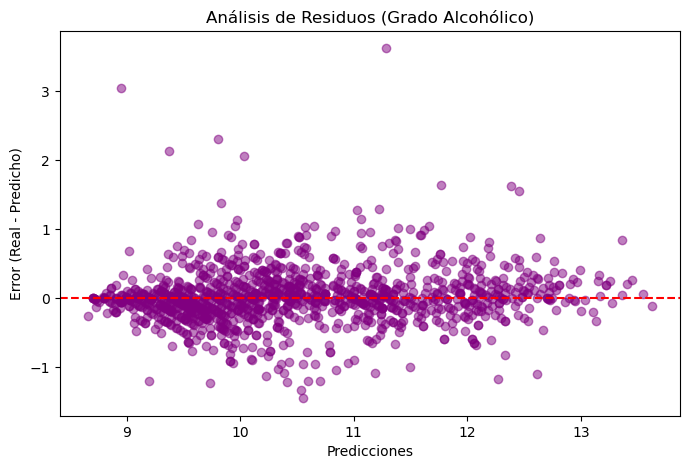

In [15]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

y_pred_final = best_reg_model.predict(X_test_r_scaled)

print(f"MAPE Final: {mean_absolute_percentage_error(y_test_r, y_pred_final)*100:.2f}%")
print(f"R² Score: {r2_score(y_test_r, y_pred_final):.4f}")

# Visualización de Residuos
plt.figure(figsize=(8, 5))
residuos = y_test_r - y_pred_final
plt.scatter(y_pred_final, residuos, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Análisis de Residuos (Grado Alcohólico)')
plt.xlabel('Predicciones')
plt.ylabel('Error (Real - Predicho)')
plt.show()

### CONCLUSIONES

Para el bloque de Regresión, el modelo alcanzó un $R^2$ de 0.8862, explicando casi el 89% de la variabilidad del alcohol. El error porcentual (MAPE) se redujo al 2.49%, cumpliendo el objetivo de negocio para simulaciones precisas. El análisis de residuos confirma una alta fiabilidad en el rango central (10-12 grados), con desviaciones mínimas en la mayoría de las muestras. Este simulador permite a la bodega predecir el etiquetado internacional con un margen de error técnico muy bajo.